In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Tell Python where our data lives
DATA_RAW = Path(r"C:\Users\syeds\OneDrive\Desktop\nboracle\nb_oracle\data\raw\store-sales-time-series-forecasting")

# Load the main sales file
train = pd.read_csv(DATA_RAW / "train.csv", parse_dates=["date"])
stores = pd.read_csv(DATA_RAW / "stores.csv")
holidays = pd.read_csv(DATA_RAW / "holidays_events.csv", parse_dates=["date"])

# Let's see what we're working with
print(f"Total sales rows: {len(train):,}")
print(f"Date range: {train.date.min().date()} to {train.date.max().date()}")
print(f"Number of stores: {train.store_nbr.nunique()}")
print(f"Number of product categories: {train.family.nunique()}")

Total sales rows: 3,000,888
Date range: 2013-01-01 to 2017-08-15
Number of stores: 54
Number of product categories: 33


In [2]:
# Let's see what the data actually looks like
# This shows the first 10 rows — like peeking at a spreadsheet
train.head(10)

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0
6,6,2013-01-01,1,CELEBRATION,0.0,0
7,7,2013-01-01,1,CLEANING,0.0,0
8,8,2013-01-01,1,DAIRY,0.0,0
9,9,2013-01-01,1,DELI,0.0,0


In [3]:
# What product categories exist?
# These are what we'll be predicting demand for
print("All product categories:")
for i, name in enumerate(sorted(train.family.unique()), 1):
    print(f"  {i}. {name}")

All product categories:
  1. AUTOMOTIVE
  2. BABY CARE
  3. BEAUTY
  4. BEVERAGES
  5. BOOKS
  6. BREAD/BAKERY
  7. CELEBRATION
  8. CLEANING
  9. DAIRY
  10. DELI
  11. EGGS
  12. FROZEN FOODS
  13. GROCERY I
  14. GROCERY II
  15. HARDWARE
  16. HOME AND KITCHEN I
  17. HOME AND KITCHEN II
  18. HOME APPLIANCES
  19. HOME CARE
  20. LADIESWEAR
  21. LAWN AND GARDEN
  22. LINGERIE
  23. LIQUOR,WINE,BEER
  24. MAGAZINES
  25. MEATS
  26. PERSONAL CARE
  27. PET SUPPLIES
  28. PLAYERS AND ELECTRONICS
  29. POULTRY
  30. PREPARED FOODS
  31. PRODUCE
  32. SCHOOL AND OFFICE SUPPLIES
  33. SEAFOOD


In [4]:
# Let's focus on ONE store to understand the patterns
# Store 44 is a good mid-size one
store44 = train[train.store_nbr == 44].copy()
print(f"Store 44 has {len(store44):,} rows of sales data")
print(f"\nAverage daily sales by category (top 10):")
top_cats = (store44.groupby("family")["sales"]
            .mean()
            .sort_values(ascending=False)
            .head(10))
print(top_cats.round(1).to_string())

Store 44 has 55,572 rows of sales data

Average daily sales by category (top 10):
family
GROCERY I       9730.4
BEVERAGES       7967.8
PRODUCE         6333.8
CLEANING        2558.3
DAIRY           2540.4
BREAD/BAKERY    1385.4
POULTRY         1239.3
MEATS            971.9
EGGS             648.4
FROZEN FOODS     606.4


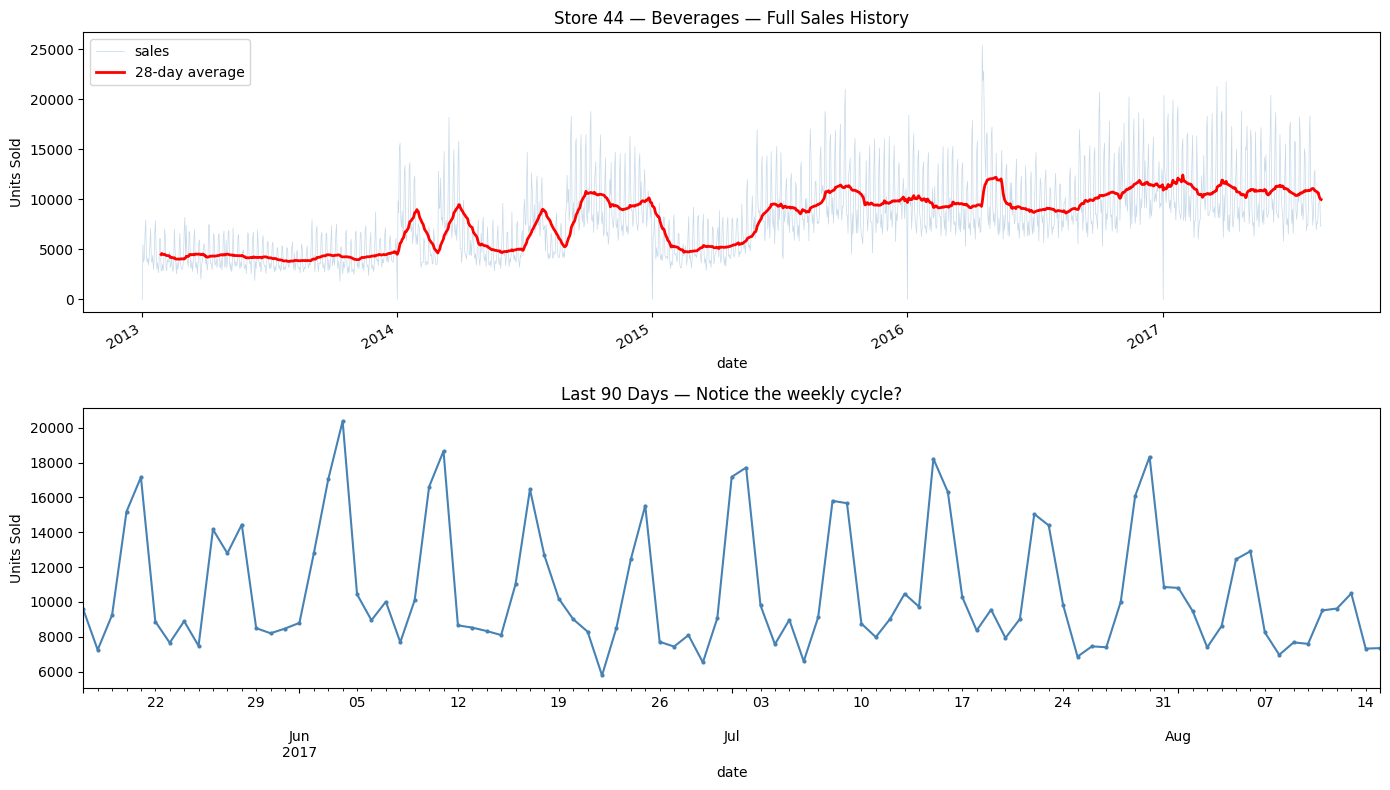

In [6]:
# Now let's VISUALIZE beverages over time

bev = store44[store44.family == "BEVERAGES"].set_index("date")["sales"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top chart: full history with a smoothed trend line
bev.plot(ax=axes[0], alpha=0.3, linewidth=0.5, color="steelblue")
bev.rolling(28).mean().plot(ax=axes[0], color="red", linewidth=2, label="28-day average")
axes[0].set_title("Store 44 — Beverages — Full Sales History")
axes[0].set_ylabel("Units Sold")
axes[0].legend()

# Bottom chart: zoom into last 3 months to see weekly patterns
last_90 = bev[bev.index >= bev.index.max() - pd.Timedelta(days=90)]
last_90.plot(ax=axes[1], marker=".", markersize=4, color="steelblue")
axes[1].set_title("Last 90 Days — Notice the weekly cycle?")
axes[1].set_ylabel("Units Sold")

plt.tight_layout()
plt.show()

In [7]:
# The zero-inflation problem
# This is WHY we use Tweedie regression instead of normal regression
# Many categories have lots of days with ZERO sales

zero_pct = (store44.groupby("family")["sales"]
    .apply(lambda x: (x == 0).mean() * 100)
    .sort_values(ascending=False))

print("Percentage of days with ZERO sales per category:")
print("(This is why normal regression doesn't work well)\n")
print(zero_pct.round(1).to_string())

Percentage of days with ZERO sales per category:
(This is why normal regression doesn't work well)

family
BABY CARE                     100.0
BOOKS                          90.1
PET SUPPLIES                   40.0
SCHOOL AND OFFICE SUPPLIES     40.0
PLAYERS AND ELECTRONICS        39.7
CELEBRATION                    39.7
LADIESWEAR                     39.7
HOME CARE                      38.0
MAGAZINES                      37.1
HOME APPLIANCES                33.7
HOME AND KITCHEN II            30.8
HOME AND KITCHEN I             30.8
LIQUOR,WINE,BEER               11.0
HARDWARE                        7.8
PRODUCE                         4.8
LAWN AND GARDEN                 3.6
BEAUTY                          0.8
LINGERIE                        0.4
AUTOMOTIVE                      0.3
GROCERY II                      0.3
GROCERY I                       0.3
DELI                            0.3
BREAD/BAKERY                    0.3
CLEANING                        0.3
DAIRY                        

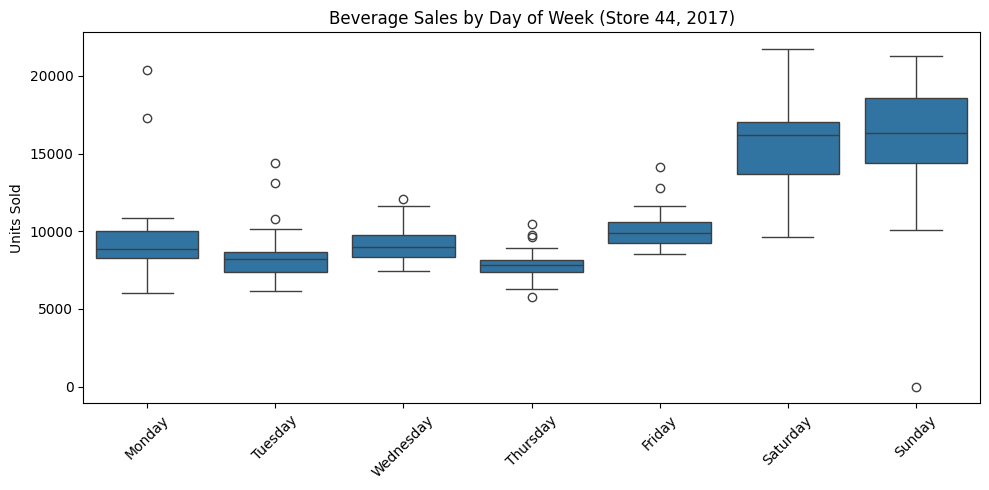

In [9]:
# Day-of-week patterns
# This proves that "which day of the week" matters for sales

bev_recent = store44[(store44.family == "BEVERAGES") &
                      (store44.date >= "2017-01-01")].copy()
bev_recent["day_name"] = bev_recent.date.dt.day_name()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=bev_recent, x="day_name", y="sales", order=day_order, ax=ax)
ax.set_title("Beverage Sales by Day of Week (Store 44, 2017)")
ax.set_xlabel("")
ax.set_ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()